In [8]:
import torch
import gc

gc.collect()
torch.cuda.empty_cache()

In [9]:
import torch
import torch.nn as nn
import torchvision.models as models
from timm import create_model

class ResViT(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        # ✅ ResNet18 (lightweight)
        self.cnn = models.resnet18(weights="IMAGENET1K_V1")
        cnn_dim = self.cnn.fc.in_features
        self.cnn.fc = nn.Identity()

        # ✅ ViT Small (fixed indentation)
        self.vit = create_model('vit_small_patch16_224', pretrained=True, num_classes=0)
        vit_dim = 384

        # ✅ Classifier
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(cnn_dim + vit_dim),
            nn.Linear(cnn_dim + vit_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        f_cnn = self.cnn(x)
        f_vit = self.vit(x)

        # CONCAT
        f = torch.cat([f_cnn, f_vit], dim=1)

        return self.classifier(f)

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = ResViT().to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

In [11]:
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler
import torch
import gc

scaler = GradScaler()

def train_model(model, train_loader, val_loader, epochs=20):
    best_acc = 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in tqdm(train_loader):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()

            # ✅ MIXED PRECISION START
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
            # ✅ MIXED PRECISION END

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()

            # ✅ OPTIONAL: free small tensors
            del outputs, loss

        scheduler.step()

        # ✅ Evaluation
        val_acc = evaluate(model, val_loader)

        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}, Val Acc: {val_acc:.4f}")

        # ✅ MEMORY CLEANUP AFTER EACH EPOCH
        gc.collect()
        torch.cuda.empty_cache()

    return model

/tmp/ipykernel_55/2102352208.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds))

    print("\nConfusion Matrix:")
    print(confusion_matrix(all_labels, all_preds))

    return correct / total

In [13]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 66.1 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=3631acecc9385246108ce29b25ca8787a2417ef7dc854c2ba0ae94ccb4313e3f
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [14]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Use last conv layer of ResNet
target_layers = [model.cnn.layer4[-1]]

cam = GradCAM(model=model, target_layers=target_layers)

def apply_gradcam(image_tensor):
    grayscale_cam = cam(input_tensor=image_tensor.unsqueeze(0))

    cam_image = show_cam_on_image(
        image_tensor.permute(1,2,0).cpu().numpy(),
        grayscale_cam[0],
        use_rgb=True
    )

    return cam_image

In [15]:
data_dir = "/kaggle/input/datasets/venkatsaikondra/venkatsaikondra67/Final_Data"

In [16]:
from torchvision import datasets, transforms

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

train_dataset = datasets.ImageFolder(
    data_dir + "/train", transform=train_transform
)

val_dataset = datasets.ImageFolder(
    data_dir + "/val", transform=val_transform
)

test_dataset = datasets.ImageFolder(
    data_dir + "/test", transform=val_transform
)

In [17]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

In [18]:
model = train_model(model, train_loader, val_loader, epochs=30)

test_acc = evaluate(model, test_loader)

print(f"Final Test Accuracy: {test_acc:.4f}")

  0%|          | 0/472 [00:00<?, ?it/s]/tmp/ipykernel_55/2102352208.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
100%|██████████| 472/472 [02:02<00:00,  3.85it/s]



Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       404
           1       0.88      0.98      0.93       404
           2       0.82      0.72      0.77       404
           3       0.76      0.76      0.76       404

    accuracy                           0.86      1616
   macro avg       0.86      0.86      0.86      1616
weighted avg       0.86      0.86      0.86      1616


Confusion Matrix:
[[403   1   0   0]
 [  2 395   0   7]
 [  0  21 292  91]
 [  1  33  63 307]]
Epoch 1, Loss: 359.4757, Val Acc: 0.8645


  0%|          | 0/472 [00:00<?, ?it/s]/tmp/ipykernel_55/2102352208.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
100%|██████████| 472/472 [01:08<00:00,  6.94it/s]



Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       404
           1       0.87      0.99      0.93       404
           2       0.80      0.79      0.80       404
           3       0.81      0.72      0.76       404

    accuracy                           0.87      1616
   macro avg       0.87      0.87      0.87      1616
weighted avg       0.87      0.87      0.87      1616


Confusion Matrix:
[[401   0   0   3]
 [  1 398   1   4]
 [  0  23 319  62]
 [  0  35  77 292]]
Epoch 2, Loss: 293.4716, Val Acc: 0.8725


  0%|          | 0/472 [00:00<?, ?it/s]/tmp/ipykernel_55/2102352208.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
100%|██████████| 472/472 [01:05<00:00,  7.18it/s]


...


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       404
           1       0.98      0.98      0.98       404
           2       0.87      0.85      0.86       404
           3       0.85      0.87      0.86       404

    accuracy                           0.92      1616
   macro avg       0.92      0.92      0.92      1616
weighted avg       0.92      0.92      0.92      1616


Confusion Matrix:
[[403   0   0   1]
 [  1 395   2   6]
 [  0   4 345  55]
 [  0   5  49 350]]
Epoch 28, Loss: 189.6177, Val Acc: 0.9239


  0%|          | 0/472 [00:00<?, ?it/s]/tmp/ipykernel_55/2102352208.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
100%|██████████| 472/472 [01:08<00:00,  6.91it/s]



Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       404
           1       0.98      0.98      0.98       404
           2       0.88      0.85      0.86       404
           3       0.85      0.87      0.86       404

    accuracy                           0.92      1616
   macro avg       0.92      0.92      0.92      1616
weighted avg       0.92      0.92      0.92      1616


Confusion Matrix:
[[403   0   0   1]
 [  1 395   2   6]
 [  0   4 343  57]
 [  0   6  46 352]]
Epoch 29, Loss: 189.2249, Val Acc: 0.9239


  0%|          | 0/472 [00:00<?, ?it/s]/tmp/ipykernel_55/2102352208.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
100%|██████████| 472/472 [01:10<00:00,  6.71it/s]



Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       404
           1       0.98      0.98      0.98       404
           2       0.86      0.85      0.85       404
           3       0.85      0.87      0.86       404

    accuracy                           0.92      1616
   macro avg       0.92      0.92      0.92      1616
weighted avg       0.92      0.92      0.92      1616


Confusion Matrix:
[[403   0   0   1]
 [  1 394   4   5]
 [  0   4 342  58]
 [  0   4  50 350]]
Epoch 30, Loss: 189.2090, Val Acc: 0.9214

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       405
           1       0.99      0.98      0.98       405
           2       0.88      0.84      0.86       405
           3       0.84      0.88      0.86       405

    accuracy                           0.92      1620
   macro avg       0.92      0.92      0.92      1620

In [19]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

In [20]:
model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)

print(all_probs.shape, all_labels.shape)

(1620, 4) (1620,)


In [21]:
num_classes = all_probs.shape[1]

all_labels_bin = label_binarize(
    all_labels,
    classes=list(range(num_classes))
)

fpr, tpr, roc_auc = {}, {}, {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

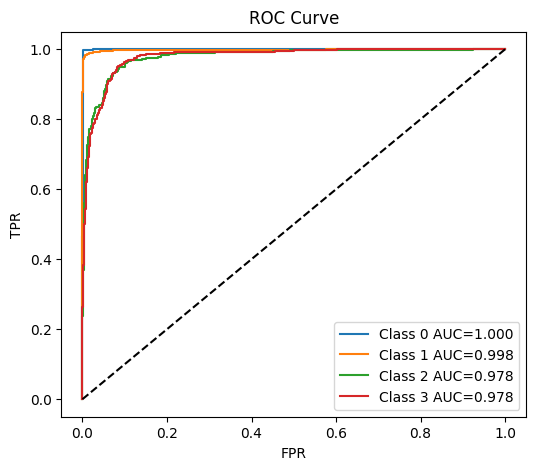

In [22]:
plt.figure(figsize=(6,5))

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} AUC={roc_auc[i]:.3f}")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [27]:
!pip install -q grad-cam

import torch
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [30]:
def reshape_transform(tensor, height=14, width=14):
    tensor = tensor[:, 1:, :]   # remove class token
    return tensor.reshape(tensor.size(0), height, width, tensor.size(2)).permute(0, 3, 1, 2)

In [33]:
for name, module in model.named_modules():
    print(name)


cnn
cnn.conv1
cnn.bn1
cnn.relu
cnn.maxpool
cnn.layer1
cnn.layer1.0
cnn.layer1.0.conv1
cnn.layer1.0.bn1
cnn.layer1.0.relu
cnn.layer1.0.conv2
cnn.layer1.0.bn2
cnn.layer1.1
cnn.layer1.1.conv1
cnn.layer1.1.bn1
cnn.layer1.1.relu
cnn.layer1.1.conv2
cnn.layer1.1.bn2
cnn.layer2
cnn.layer2.0
cnn.layer2.0.conv1
cnn.layer2.0.bn1
cnn.layer2.0.relu
cnn.layer2.0.conv2
cnn.layer2.0.bn2
cnn.layer2.0.downsample
cnn.layer2.0.downsample.0
cnn.layer2.0.downsample.1
cnn.layer2.1
cnn.layer2.1.conv1
cnn.layer2.1.bn1
cnn.layer2.1.relu
cnn.layer2.1.conv2
cnn.layer2.1.bn2
cnn.layer3
cnn.layer3.0
cnn.layer3.0.conv1
cnn.layer3.0.bn1
cnn.layer3.0.relu
cnn.layer3.0.conv2
cnn.layer3.0.bn2
cnn.layer3.0.downsample
cnn.layer3.0.downsample.0
cnn.layer3.0.downsample.1
cnn.layer3.1
cnn.layer3.1.conv1
cnn.layer3.1.bn1
cnn.layer3.1.relu
cnn.layer3.1.conv2
cnn.layer3.1.bn2
cnn.layer4
cnn.layer4.0
cnn.layer4.0.conv1
cnn.layer4.0.bn1
cnn.layer4.0.relu
cnn.layer4.0.conv2
cnn.layer4.0.bn2
cnn.layer4.0.downsample
cnn.layer4.0.do

In [41]:
import torch
import torch.nn.functional as F

class RISE:
    def __init__(self, model, input_size, device):
        self.model = model
        self.input_size = input_size
        self.device = device

    def generate_masks(self, N=1000, s=8, p1=0.5):
        cell_size = np.ceil(np.array(self.input_size) / s)
        up_size = (s + 1) * cell_size

        masks = []
        for _ in range(N):
            grid = np.random.rand(s, s) < p1
            grid = grid.astype('float32')

            mask = torch.tensor(grid)
            mask = F.interpolate(mask.unsqueeze(0).unsqueeze(0),
                                 size=tuple(up_size.astype(int)),
                                 mode='bilinear',
                                 align_corners=False)

            x = np.random.randint(0, cell_size[0])
            y = np.random.randint(0, cell_size[1])

            mask = mask[:, :, x:x+self.input_size[0], y:y+self.input_size[1]]
            masks.append(mask)

        self.masks = torch.cat(masks).to(self.device)
        return self.masks

    def explain(self, input_tensor, class_idx):
        N = self.masks.size(0)

        masked = input_tensor * self.masks
        preds = []

        for i in range(0, N, 32):
            batch = masked[i:i+32]
            with torch.no_grad():
                out = self.model(batch)
                preds.append(out[:, class_idx])

        preds = torch.cat(preds)
        saliency = (preds.view(-1, 1, 1, 1) * self.masks).sum(0)
        saliency = saliency.squeeze().cpu().numpy()

        saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min())
        return saliency

In [42]:
model.eval()

rise = RISE(model, input_size=(224, 224), device=device)

rise.generate_masks(N=1000)

input_tensor = images[0:1].to(device)
class_idx = labels[0].item()

saliency = rise.explain(input_tensor, class_idx)

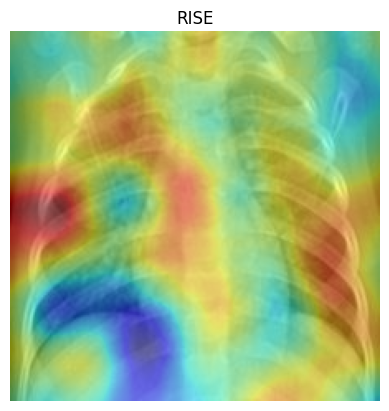

In [43]:
img = input_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
img = (img - img.min()) / (img.max() - img.min())

plt.imshow(img)
plt.imshow(saliency, cmap='jet', alpha=0.5)
plt.axis('off')
plt.title("RISE")
plt.show()